In [29]:
import pandas as pd

In [30]:
table = pd.read_csv("/content/titanic_task1_dataset.csv")

In [31]:
table

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Ali Khan,male,22.0,1,0,7.25,S
1,2,1,1,Sara Ahmed,female,38.0,1,0,71.28,C
2,3,1,3,John Smith,female,NaN,0,0,8.05,S
3,4,0,1,Emma Brown,female,35.0,1,0,53.10,S
4,5,1,2,David Lee,male,28.0,0,1,16.00,C
5,6,0,3,Aisha Patel,female,19.0,0,0,13.00,NaN
6,7,1,1,Michael Jones,male,40.0,1,0,35.50,S
7,8,0,3,Fatima Noor,female,NaN,3,1,21.07,S
8,9,1,2,Robert Wilson,male,30.0,0,0,15.50,C
9,10,0,3,Sophia Davis,female,26.0,1,0,9.80,S


In [32]:
table.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Ali Khan,male,22.0,1,0,7.25,S
1,2,1,1,Sara Ahmed,female,38.0,1,0,71.28,C
2,3,1,3,John Smith,female,NaN,0,0,8.05,S
3,4,0,1,Emma Brown,female,35.0,1,0,53.10,S
4,5,1,2,David Lee,male,28.0,0,1,16.00,C
5,6,0,3,Aisha Patel,female,19.0,0,0,13.00,NaN
6,7,1,1,Michael Jones,male,40.0,1,0,35.50,S
7,8,0,3,Fatima Noor,female,NaN,3,1,21.07,S
8,9,1,2,Robert Wilson,male,30.0,0,0,15.50,C
9,10,0,3,Sophia Davis,female,26.0,1,0,9.80,S


In [33]:
table.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  20 non-null     int64  
 1   Survived     20 non-null     int64  
 2   Pclass       20 non-null     int64  
 3   Name         20 non-null     object 
 4   Sex          20 non-null     object 
 5   Age          17 non-null     float64
 6   SibSp        20 non-null     int64  
 7   Parch        20 non-null     int64  
 8   Fare         19 non-null     float64
 9   Embarked     19 non-null     object 
dtypes: float64(2), int64(5), object(3)
memory usage: 1.7+ KB


In [34]:
table.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,3
SibSp,0
Parch,0
Fare,1
Embarked,1


In [35]:
table.Age

,Age
0,22.0
1,38.0
2,NaN
3,35.0
4,28.0
5,19.0
6,40.0
7,NaN
8,30.0
9,26.0


In [36]:
# filling the null in internship column by using fillna() and median() method
table['Age'] = table['Age'].fillna(table['Age'].median())

In [37]:
table.Age

,Age
0,22.0
1,38.0
2,30.0
3,35.0
4,28.0
5,19.0
6,40.0
7,30.0
8,30.0
9,26.0


In [38]:
table['Fare'] = table['Fare'].fillna(table['Fare'].mode())


In [39]:
table.Fare

,Fare
0,7.25
1,71.28
2,8.05
3,53.10
4,16.00
5,13.00
6,35.50
7,21.07
8,15.50
9,9.80


In [44]:
table['Embarked'] = table['Embarked'].fillna(table['Embarked'].mode()[0])


In [45]:
table.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [46]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()



In [47]:
# converting the text labels to numerically or binary using label encoder
table['Sex'] = le.fit_transform(table['Sex'])

In [50]:
# converting the text labels to numerically or binary using label encoder
table['Embarked'] = le.fit_transform(table['Embarked'])

In [51]:
table.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,Ali Khan,1,22.0,1,0,7.25,2
1,2,1,1,Sara Ahmed,0,38.0,1,0,71.28,0
2,3,1,3,John Smith,0,30.0,0,0,8.05,2
3,4,0,1,Emma Brown,0,35.0,1,0,53.10,2
4,5,1,2,David Lee,1,28.0,0,1,16.00,0


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

columns_to_scale = ["Age", "Fare", "SibSp", "Parch"]
table[columns_to_scale] = scaler.fit_transform(table[columns_to_scale])



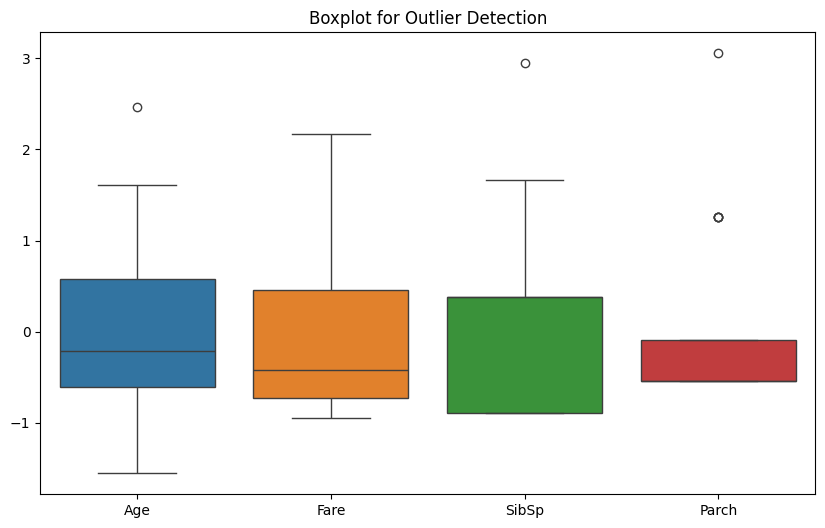

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.boxplot(data=table[["Age", "Fare", "SibSp", "Parch"]])

plt.title("Boxplot for Outlier Detection")
plt.show()

In [58]:
Q1 = table[["Age", "Fare", "SibSp", "Parch"]].quantile(0.25)
Q3 = table[["Age", "Fare", "SibSp", "Parch"]].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

table_clean = table[
    ~((table[["Age", "Fare", "SibSp", "Parch"]] < lower_bound) |
      (table[["Age", "Fare", "SibSp", "Parch"]] > upper_bound)).any(axis=1)
]

print("Original rows:", len(table))
print("Rows after removing outliers:", len(table_clean))

Original rows: 20
Rows after removing outliers: 14


In [60]:
print(table_clean.head())
print("\nShape:", table_clean.shape)
print("\nMissing Values:")
print(table_clean.isnull().sum())

   PassengerId  Survived  Pclass         Name  Sex       Age     SibSp  \
0            1         0       3     Ali Khan    1 -1.186842  0.384111   
1            2         1       1   Sara Ahmed    0  0.760796  0.384111   
2            3         1       3   John Smith    0 -0.213023 -0.896258   
3            4         0       1   Emma Brown    0  0.395614  0.384111   
5            6         0       3  Aisha Patel    0 -1.552024 -0.896258   

      Parch      Fare  Embarked  
0 -0.538816 -0.940561         2  
1 -0.538816  1.795033         0  
2 -0.538816 -0.906382         2  
3 -0.538816  1.018318         2  
5 -0.538816 -0.694900         2  

Shape: (14, 10)

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64


In [61]:
table_clean.to_csv("cleaned_titanic_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
